# LSTM

In [1]:
import urllib.request

url = "https://www.gutenberg.org/files/2701/2701-0.txt"
text = urllib.request.urlretrieve(url, "moby_dick.txt")
with open("moby_dick.txt", encoding="utf-8") as f:
    text = f.read()


start = text.find("*** START OF")
end = text.find("*** END OF")
text = text[text.find("\n", start):end]
text = text[27157::]

In [2]:
import numpy as np
from collections import Counter

cut_len = 2**12 + 1
text = text
text = text[:cut_len]

count = Counter(text)

chars = sorted(set(text))
vocab = {c: i for i, c in enumerate(chars)}
inv_vocab = {i: c for c, i in vocab.items()}
vocab_size = len(vocab)

encoded = np.array([vocab[c] for c in text])
onehot = np.eye(vocab_size)[encoded]

seq_len = 32
x = onehot[:-1].reshape(-1, seq_len, vocab_size)
y = onehot[1:].reshape(-1, seq_len, vocab_size)

print(count)
print(f"Unique tokens: {vocab_size}")
print(f"Total tokens: {len(encoded)}")
print(f"x shape: {x.shape}")

Counter({' ': 660, 'e': 442, 't': 294, 'a': 237, 's': 225, 'o': 219, 'i': 215, 'n': 213, 'h': 192, 'r': 188, 'l': 152, 'd': 114, 'u': 89, 'm': 87, 'y': 70, 'f': 70, 'p': 69, '\n': 68, 'g': 66, 'w': 63, 'c': 61, ',': 49, '.': 37, 'b': 37, 'v': 32, 'k': 20, 'I': 15, ';': 12, '—': 10, 'T': 9, 'S': 8, 'C': 7, 'W': 6, '-': 6, '?': 6, 'z': 5, 'x': 5, 'H': 4, 'A': 4, 'B': 4, 'L': 3, 'N': 3, 'q': 3, '’': 3, 'P': 2, 'R': 2, '!': 2, 'Y': 2, 'E': 1, '1': 1, 'M': 1, 'G': 1, 'j': 1, 'O': 1, 'D': 1})
Unique tokens: 55
Total tokens: 4097
x shape: (128, 32, 55)


In [3]:
from NNLibrary.network import Network
from NNLibrary.Layers.learnable import RNN, LSTM
from NNLibrary.Layers.activations import Sigmoid, Softmax

network = Network(
    layers=[
        LSTM(in_dim=vocab_size, hidden_dim=32, out_dim=vocab_size),
        # Sigmoid(),
        # Softmax(),
    ]
)

n_params = network.count_parameters()
print(f"Total parameter count: {n_params}")

Total parameter count: 13079


In [4]:
from NNLibrary.Layers.activations import Softmax

def sample_text(network, length=64, T=1, np_seed=None, seed=" "):
    np.random.seed(np_seed)
    softmax = Softmax(T=T)

    context = [onehot[vocab[seed]]] # List of one-hot

    out_seq = seed

    for _ in range(length):
        x_in = np.expand_dims(np.array(context), axis=0)
        logits = network.forward(x_in)
        pred = softmax.forward(logits)

        next_id = np.random.choice(vocab_size, p=pred[0, -1])
        next_ch = inv_vocab[next_id]

        out_seq += next_ch
        # print(onehot[inv_vocab[next_id]])
        context.append(onehot[next_id])

    print(out_seq)
    return out_seq

In [ ]:
# TODO:
# Fix dataloader batches if not divisible by 2
# Maybe remove out from LSTM and pass hidden layer to allow for stacking layers - use linear to get output 

Epoch 0
Loss: 3.991205657229493
 nxG,nmH-sikIsG ke-M’MYeHdpbOumiGS’nsw-yA Asahhb.vWWPhStCPW1AgYsa
Epoch 100
Loss: 2.5981994206068295
 COtloeht   

,r  ors xy o
ts 
 gtuda ry osg
coi ov e agtnnr hcht
Epoch 200
Loss: 2.2970316755423763
 x!qhnsty .   -?
Mp 
u  sy e—tee
aeytrd  , 
oo   o 
yir e ,
oaeey
Epoch 300
Loss: 2.127467072178901
 qTCoetttlthr,
aeraeeee,gir    ;B;ptltlloowmooaee ee oi o osssslo
Epoch 400
Loss: 1.9975327741219768
 eWye ai-iesaae iyoocnfooitstlhnf e , , Btlltr
ae
rncsnwhr   W ,

Epoch 500
Loss: 1.8691546845271803
 -Si   T?W,W,.’    1 EGy;geccoouotttsdsshnn  
nnt   —tlmaiainn
,t
Epoch 600
Loss: 1.7567212072071587
 obtlbd 
,a,,ctnt  —tnd 
ltldiyaaeeeeigi,,idtifir, ay,eixd  ,,si,
Epoch 700
Loss: 1.6632859279103822
 Ooltv yr    
ROYCoeuoayeitmaooeeeieeeeeeeitelphtdlIetntlsyaidtd 
Epoch 800
Loss: 1.571506531765153
 iA WyePr
LPltscmaimeaaeeeigte,syictid  ,snf,,,dnI ,Weeaeietk  , 
Epoch 900
Loss: 1.5065250157402739
 AL 1   PDPk HPTe;baeiveaaeeeeipdiaeoiaae,eipti-u,ti,i,,,,,,d

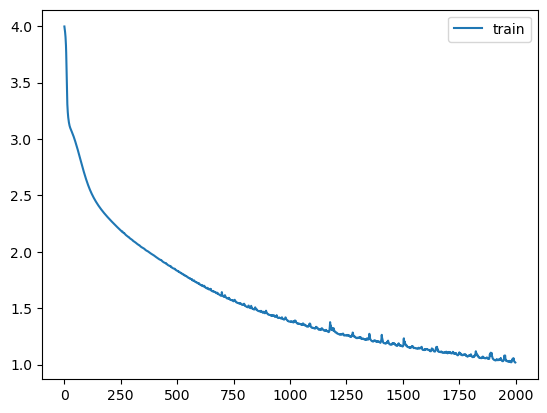

In [5]:
import matplotlib.pyplot as plt
from NNLibrary.Layers.loss import CrossEntropy, SoftmaxCE
from NNLibrary.optimizers import Adam, GradientDescent
from NNLibrary.data import DataLoader

batch_size = 32
dataloader = DataLoader(x, y, batch_size)
xb, yb = dataloader.get_batches()
n_batches = len(xb)

epochs = 2000
lr = 0.001

loss_fn = SoftmaxCE()
optimizer = Adam(lr, beta=0.9, gamma=0.999)
# optimizr = GradientDescent(lr=lr)

metrics = {"train": {"loss": [], "epoch": []}, "val": {"loss": [], "epoch": []}, "epochs": []}

for epoch in range(epochs):
    network.train()
    metrics["epochs"].append(epoch)

    train_loss = 0
    for batch in range(n_batches):

        out = network.forward(xb[batch])
        loss = loss_fn.forward(out, yb[batch])
        train_loss += loss

        network.backprop(loss_fn, optimizer) # Backpropagation and weight updates
    dataloader.shuffle_batches()

    metrics["train"]["loss"].append(train_loss / n_batches)
    metrics["train"]["epoch"].append(epoch)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}")
        print(f"Loss: {loss}")
        out_seq = sample_text(network, T=1)


plt.plot(metrics["train"]["epoch"], metrics["train"]["loss"], label="train")
plt.legend()
plt.show()

In [12]:
out_seq = sample_text(network, length=64, T=1, seed=" ")


 A PPPPfN WWWB—Ooeeeilbvoireist.,. ILaeueiptlytp,,,,,,i,,,,,lliit
